<span style='font-size:40px; display:block;'>
<b>
    Ustar filtering
</b>
</br>

---

# **BACKGROUND**

---

Filtering NEE, FN2O and FCH4 using the seasonal ustar thresholds detected with ReddyProc.
The purpose is to exclude fluxes calculated in periods with insufficient turbulence, thus avoiding biases in fluxes.

---

# **IMPORTS**

---

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


---

# **LOAD DATA**

---

In [2]:
FILEPATH = r"61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
maindf = load_parquet(filepath=FILEPATH)
maindf

Loaded .parquet file 61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.273 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FCH4_L3.1_L3.2_QCF0,Ustar_U16_Thres_reddyproc,Ustar_U50_Thres_reddyproc,Ustar_U84_Thres_reddyproc,NEE_U16_f_reddyproc,NEE_U50_f_reddyproc,NEE_U84_f_reddyproc,GPP_U16_f_reddyproc,GPP_U50_f_reddyproc,GPP_U84_f_reddyproc,Reco_U16_reddyproc,Reco_U50_reddyproc,Reco_U84_reddyproc,LE_f_reddyproc,H_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-16 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.084582,0.109093,0.134977,1.459812,1.461735,1.489906,0.108129,0.127796,0.156144,1.567941,1.589532,1.646051,5.547594,-10.692948
2023-10-16 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.084582,0.109093,0.134977,1.450082,1.451357,1.478488,0.117859,0.138175,0.167562,1.567941,1.589532,1.646051,5.547594,-10.692948
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.084582,0.109093,0.134977,1.432370,1.432507,1.450670,0.077955,0.099241,0.136408,1.510325,1.531747,1.587078,5.556566,-9.246736
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.084582,0.109093,0.134977,1.424641,1.424261,1.441940,0.043256,0.064918,0.101674,1.467896,1.489179,1.543615,5.537643,-10.266117
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.084582,0.109093,0.134977,1.428483,1.428362,1.445870,0.058188,0.079654,0.116980,1.486671,1.508017,1.562851,5.556566,-9.246736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,1014.14,1.14108,0.025231,1157.22,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.089121,0.109520,0.134977,4.545872,4.603141,4.473330,-0.543295,-0.559160,-0.374926,4.002577,4.043981,4.098404,4.951884,-5.818081
2024-08-22 22:15:00,1014.10,1.14388,0.025170,1160.01,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.089121,0.109520,0.134977,4.394256,4.437373,4.399418,-0.486607,-0.488269,-0.395766,3.907649,3.949104,4.003652,3.541709,-5.297809
2024-08-22 22:45:00,1014.08,1.14405,0.025167,1160.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.089121,0.109520,0.134977,4.523599,4.580435,4.473330,-0.545417,-0.560833,-0.399270,3.978182,4.019602,4.074060,4.850506,-5.818081


## Select the variables we are interested in

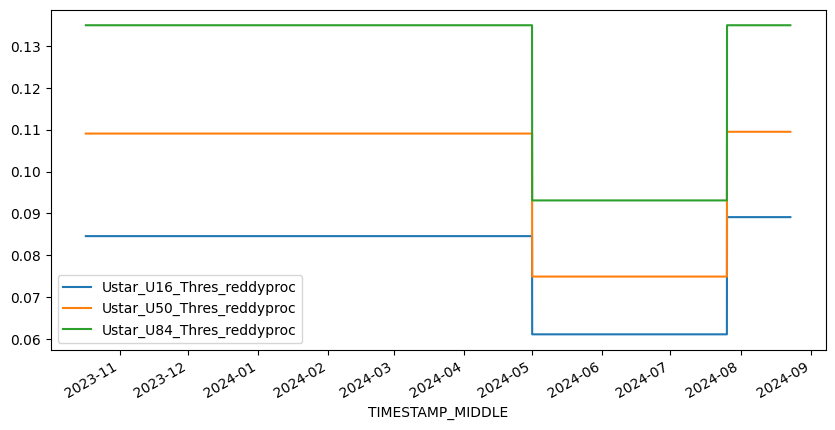

In [3]:
USTAR_SCENARIOS = ['Ustar_U16_Thres_reddyproc', 'Ustar_U50_Thres_reddyproc', 'Ustar_U84_Thres_reddyproc']
maindf[USTAR_SCENARIOS].plot(x_compat=True, figsize=(10, 5));

In [4]:
FLUX_VARS = [c for c in maindf.columns if 'L3.1_L3.2' in c]
TO_BE_FILTERED = ['NEE', 'FN2O', 'FCH4']
VARS_TO_FILTER = [c for c in FLUX_VARS if c.startswith(tuple(TO_BE_FILTERED))]
maindf[VARS_TO_FILTER]

,NEE_L3.1_L3.2_QCF,NEE_L3.1_L3.2_QCF0,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0,FCH4_L3.1_L3.2_QCF,FCH4_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,
2023-10-16 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-16 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,0.715026,NaN,-14.38638,NaN
2024-08-22 22:15:00,NaN,NaN,2.623038,NaN,49.83810,NaN
2024-08-22 22:45:00,NaN,NaN,1.743544,NaN,NaN,NaN


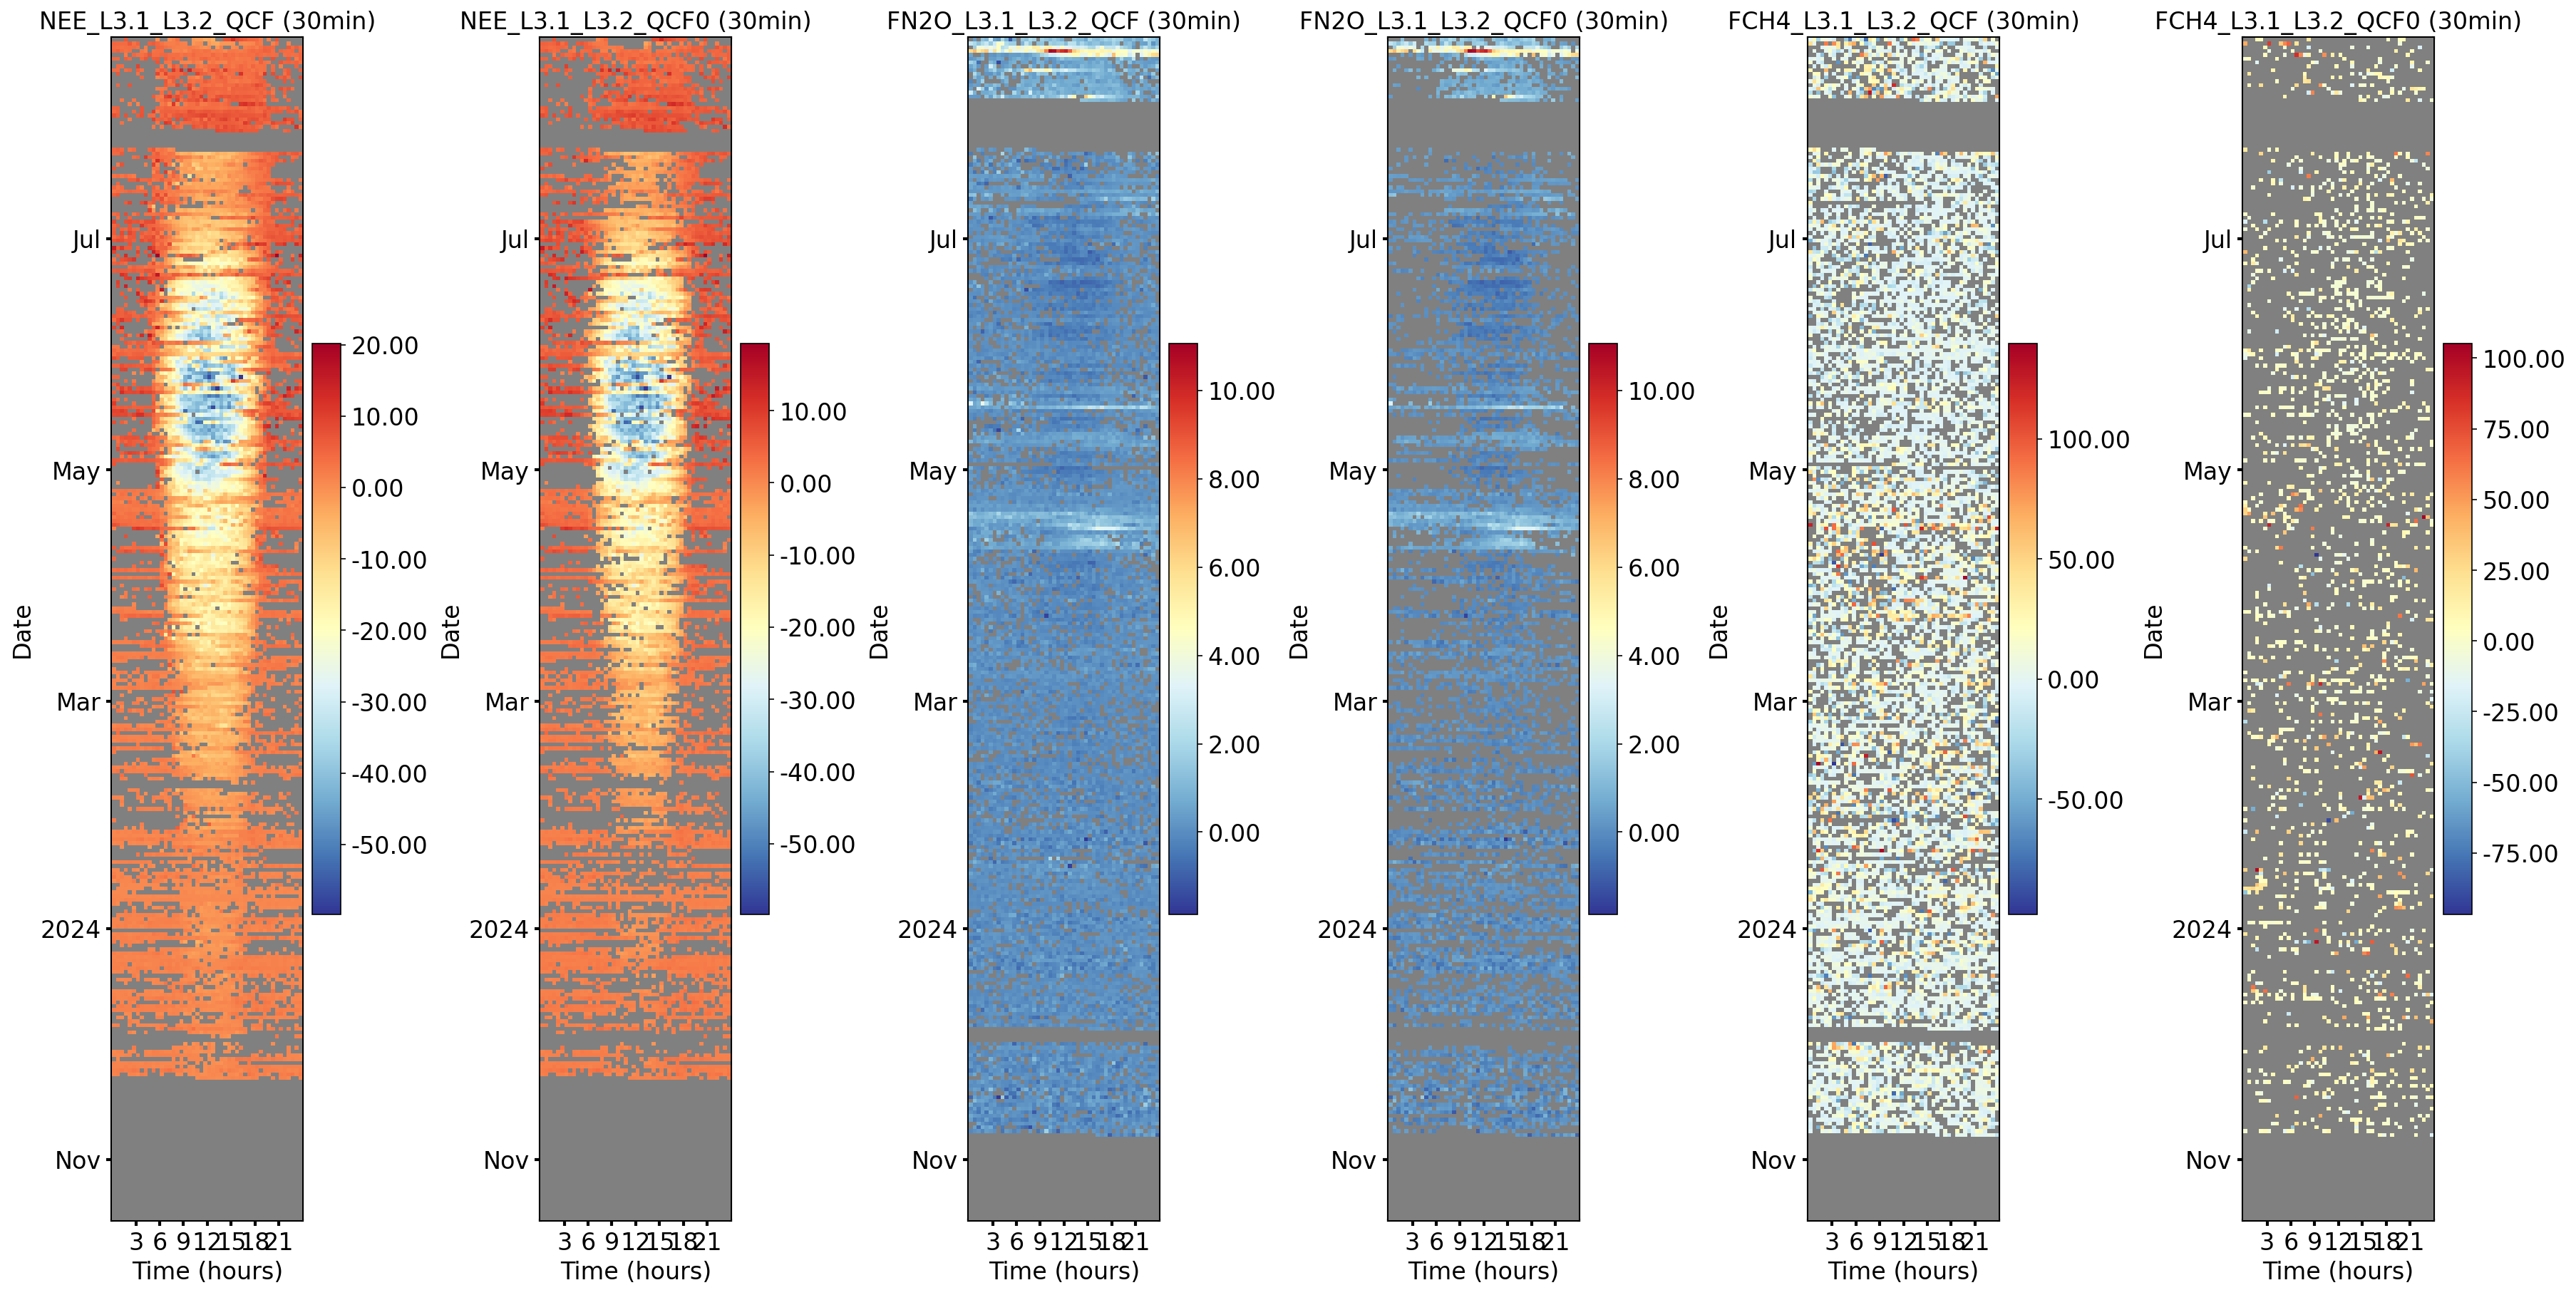

In [5]:
# Plot the fluxes that will be filtered

fig, axs = plt.subplots(ncols=6, nrows=1, figsize=(24, 12), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, VARS_TO_FILTER):
    HeatmapDateTime(series=maindf[var], ax=ax).plot()

</br>

</br>

---

# **USTAR FILTERING**

---

In [6]:
df_new = maindf.copy()

for var in VARS_TO_FILTER:
    n_total = df_new[var].notna().sum()   # valid values in original variable
    for cut in USTAR_SCENARIOS:
        CUT = cut[7:9]
        name_var = f"{var.split('_', 1)[0]}_L3.3_CUT_{CUT}_{var.rsplit('_', 1)[-1]}"
        name_flag = f"FLAG_L3.3_CUT_{CUT}_{var.split('_', 1)[0]}_L3.2_{var.rsplit('_', 1)[-1]}_USTAR_TEST"
        # Initialize if new
        if name_var not in df_new:
            df_new[name_var] = np.nan
        if name_flag not in df_new:
            df_new[name_flag] = 0.0
        valid_mask = df_new[var].notna()
        mask = df_new["USTAR"] > df_new[cut]
        df_new.loc[mask & valid_mask, name_var]  = df_new.loc[mask, var]
        df_new.loc[~mask & valid_mask, name_flag] = 2.0
        # Print stats
        n_out = (df_new[name_flag] == 2.0).sum()
        pct   = 100 * n_out / n_total if n_total > 0 else np.nan
        print(f"USTAR threshold CUT_{int(CUT)} removed "
              f"{n_out} values, {pct:.1f}% of {var}")

USTAR threshold CUT_16 removed 1024 values, 11.5% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 1605 values, 18.0% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 2285 values, 25.7% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 748 values, 9.6% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1188 values, 15.3% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 1742 values, 22.5% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 1840 values, 17.3% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2770 values, 26.0% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 3708 values, 34.8% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 664 values, 10.2% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1002 values, 15.3% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 1420 values, 21.7% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 1511 values, 18.0% of FCH4_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2290 values, 27.3% of FCH4_L3.1_L3.2

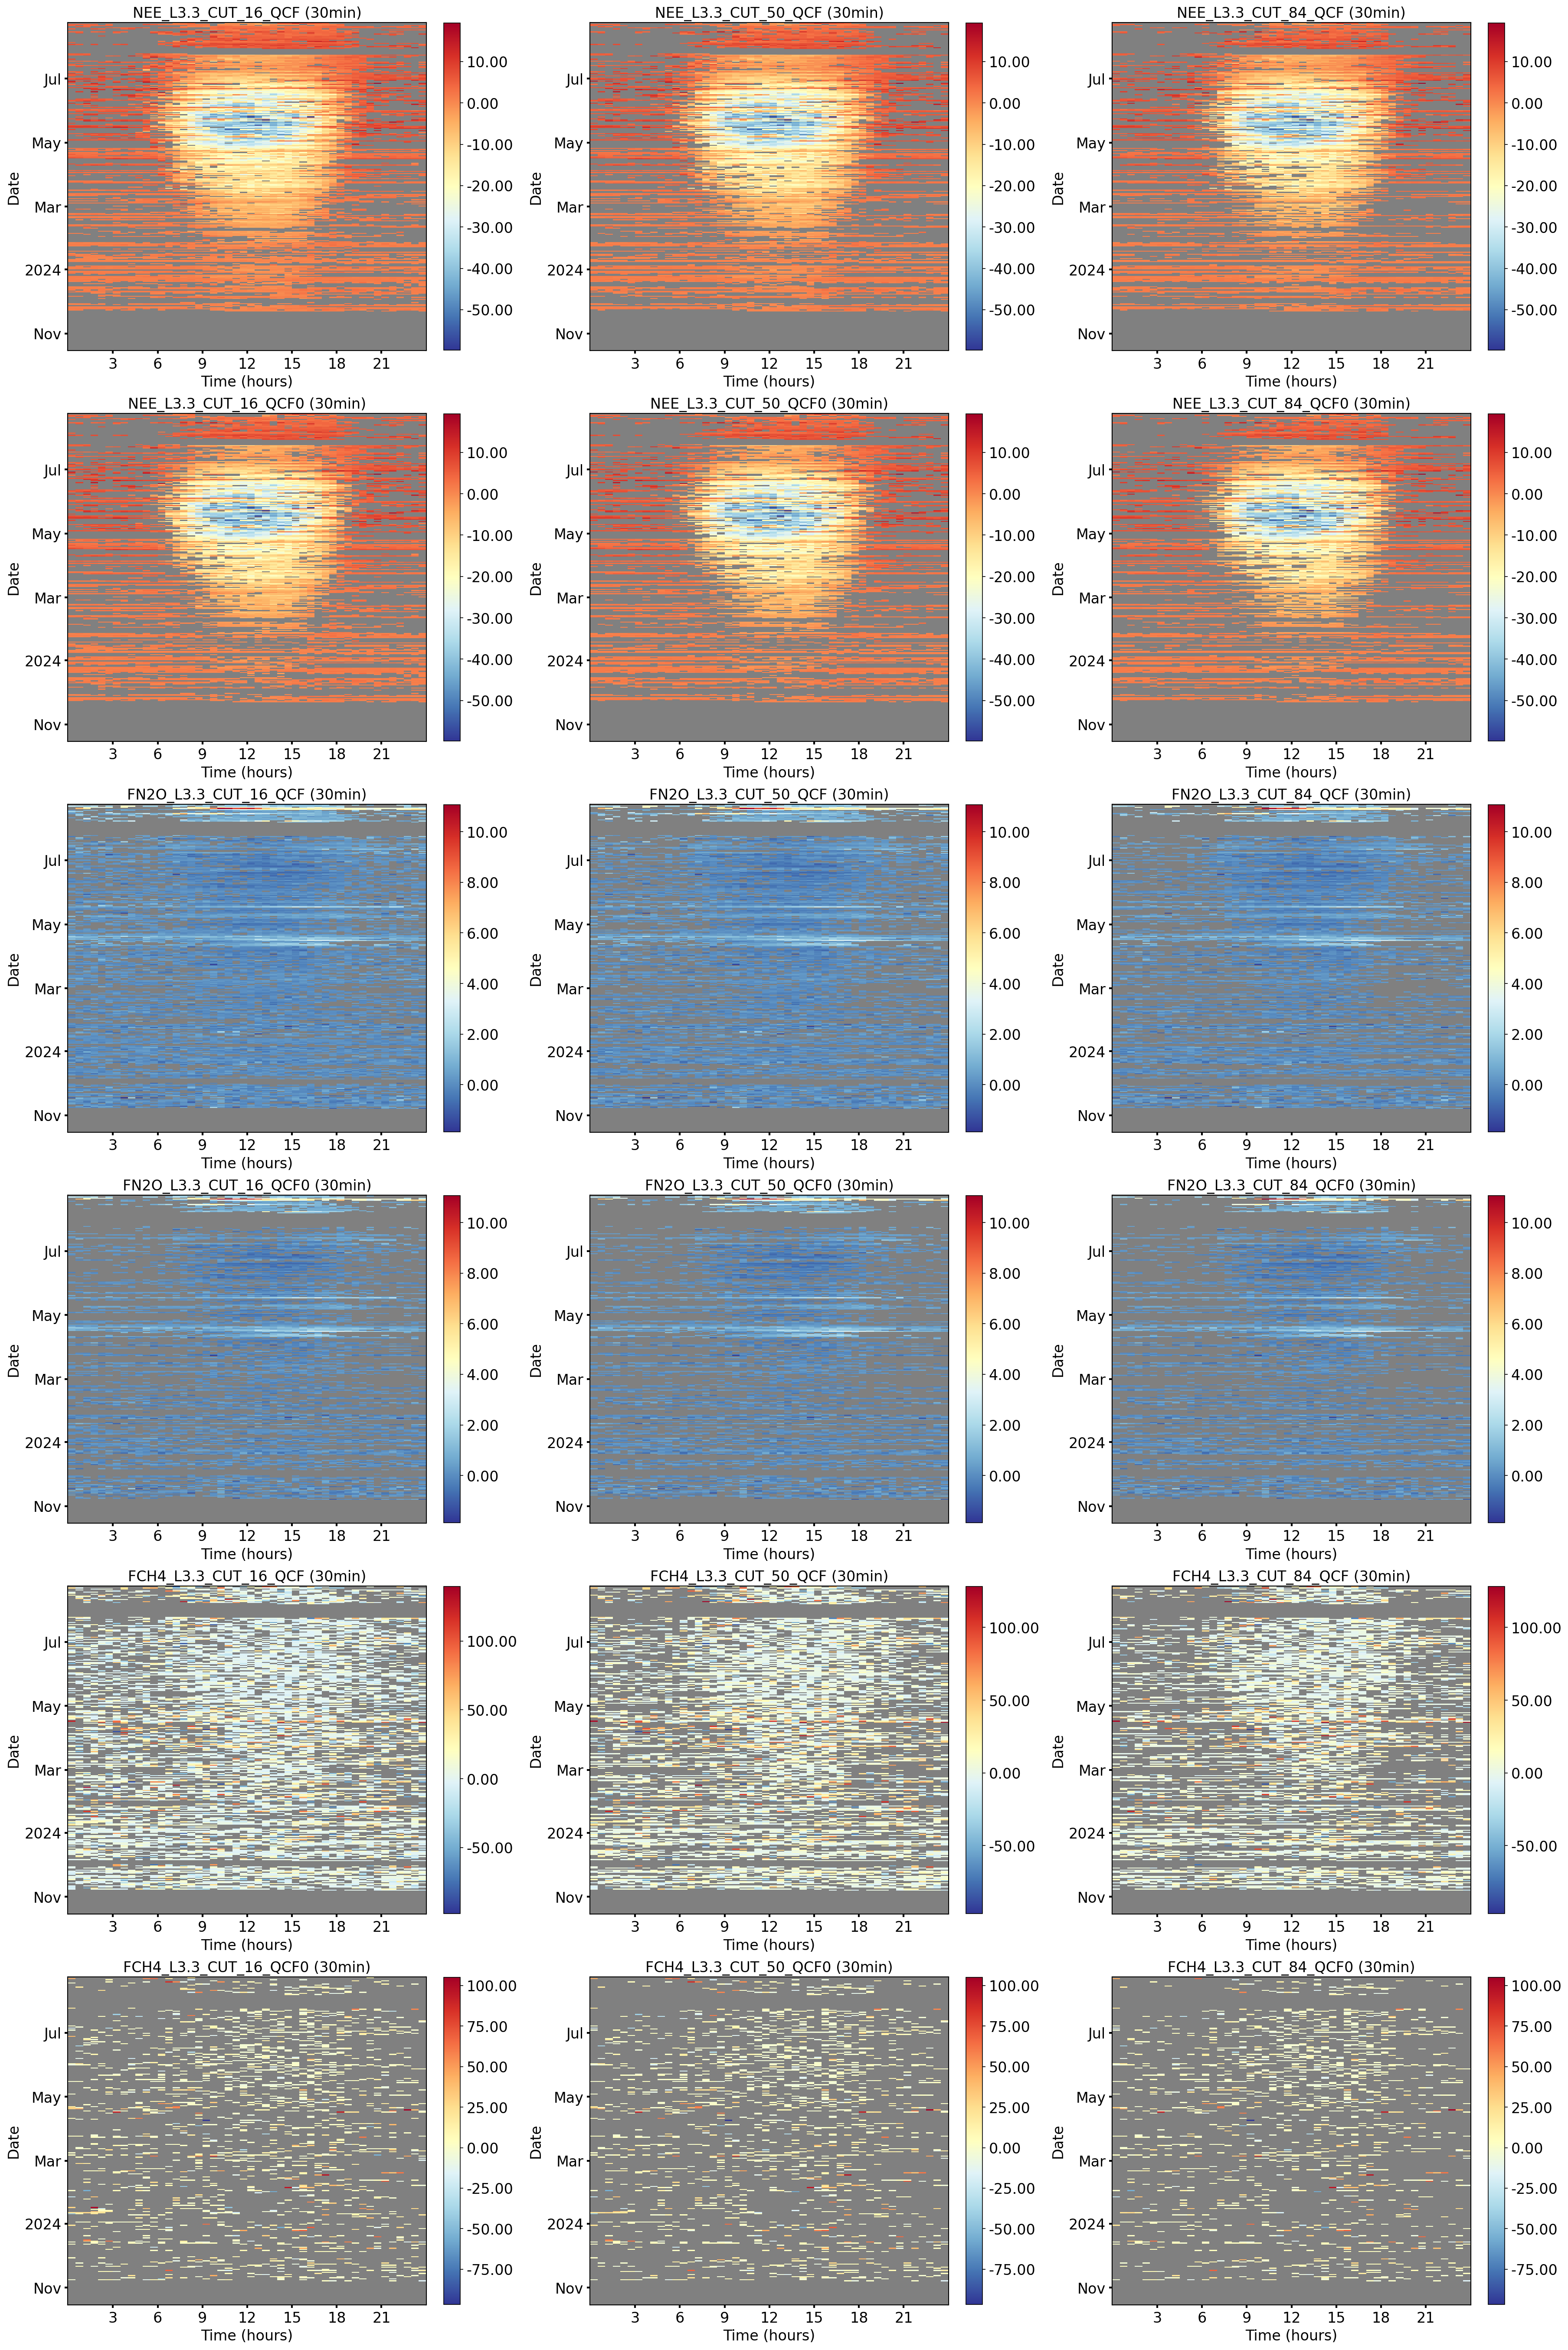

In [7]:
# Plot the ustar-filtered fluxes 
cols_to_plot  = [c for c in df_new.columns if 'CUT' in c and 'TEST' not in c]

fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(24, 36), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, cols_to_plot):
    HeatmapDateTime(series=df_new[var], ax=ax).plot()

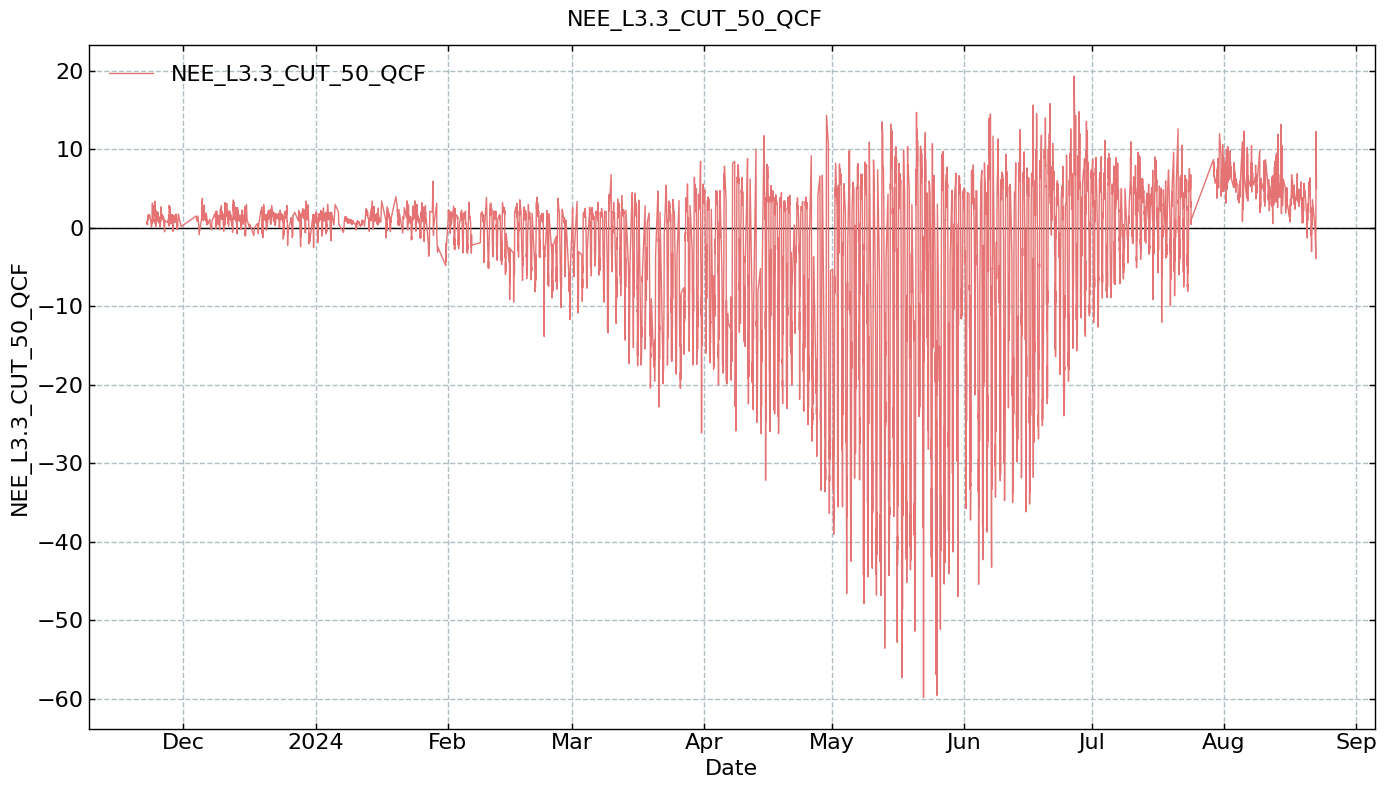

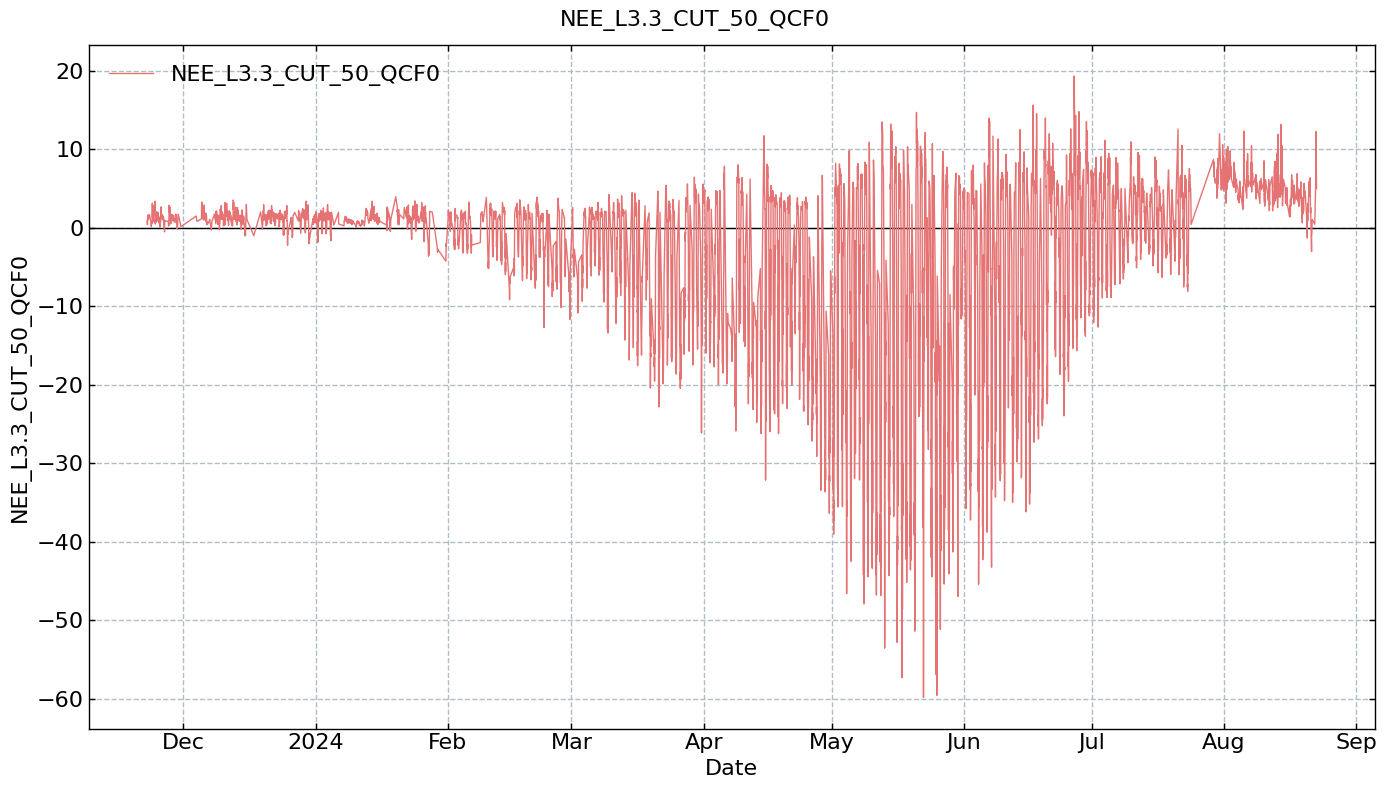

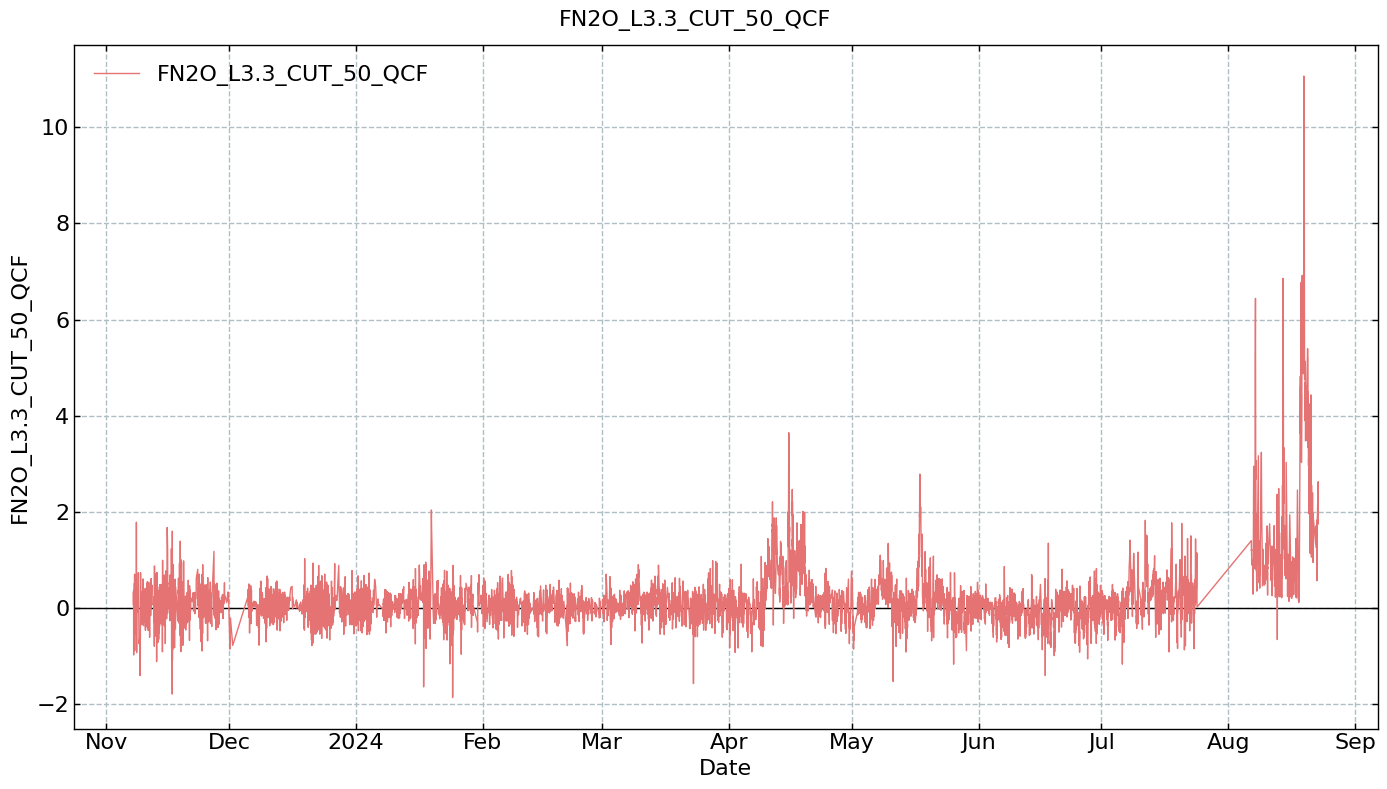

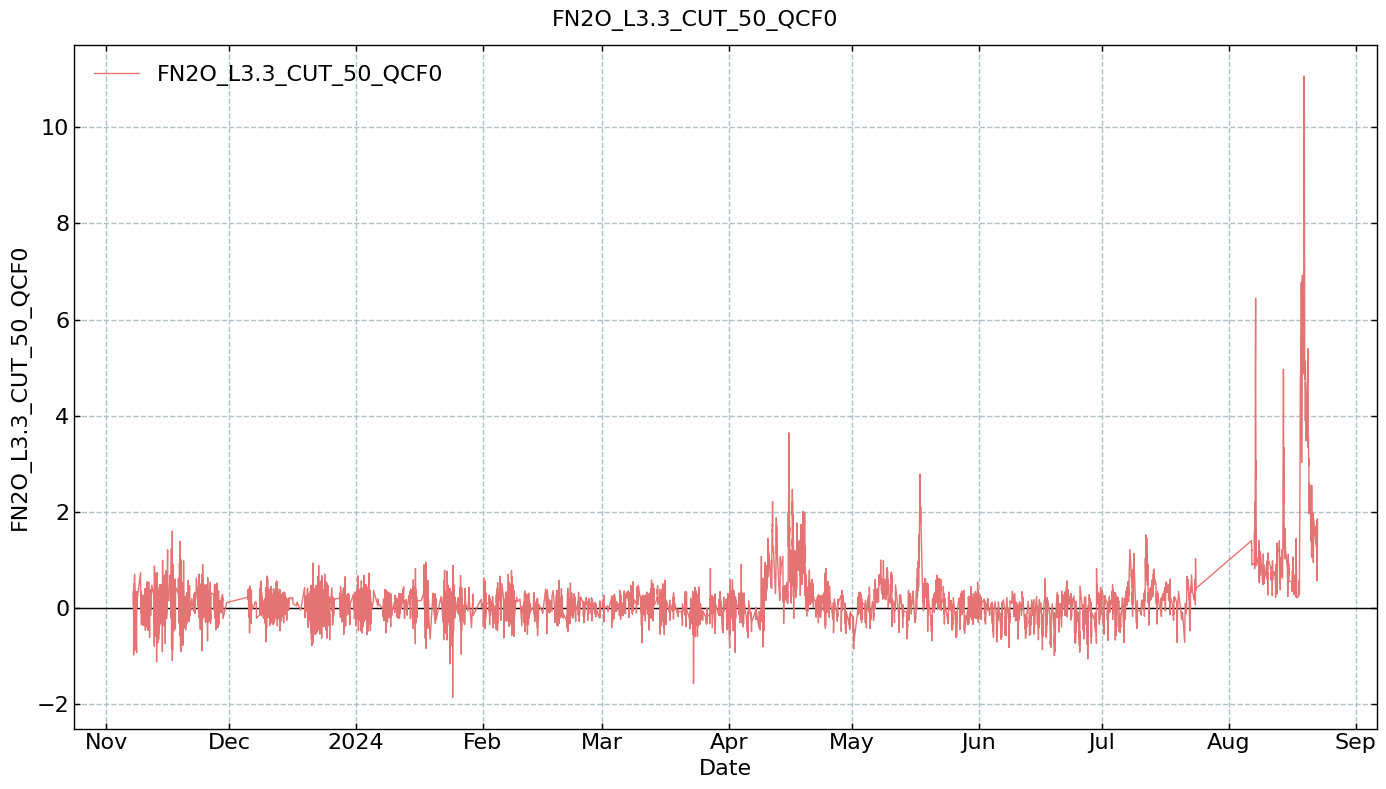

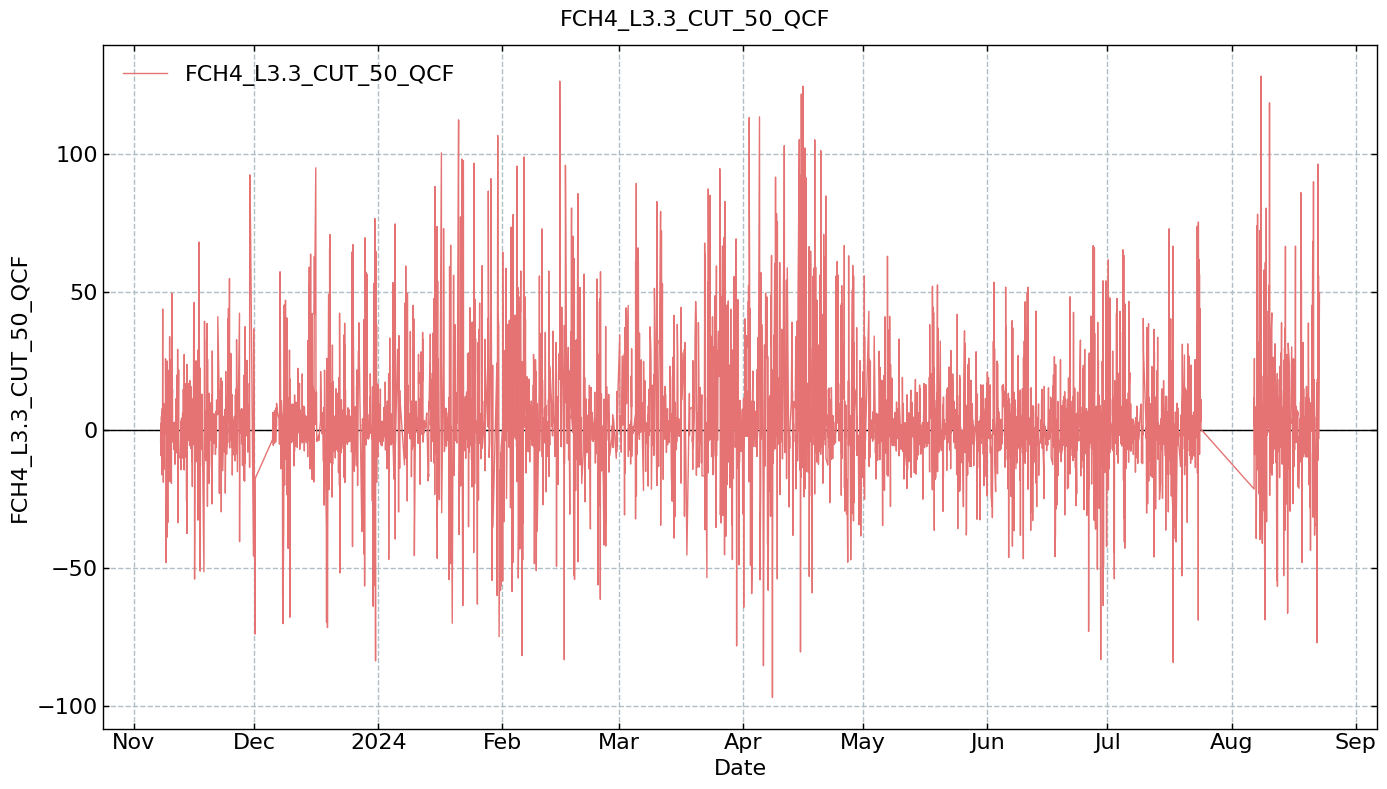

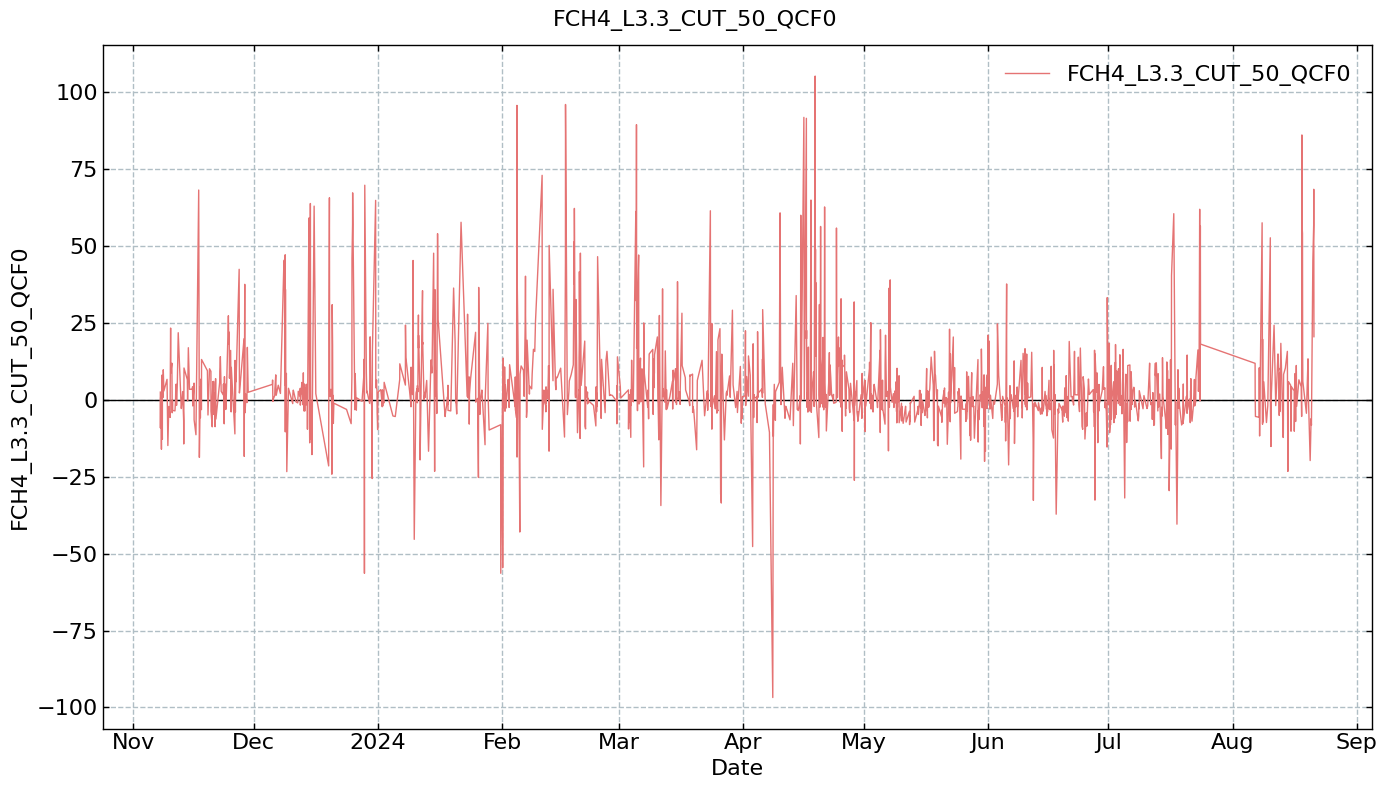

In [8]:
# Plot the variables that will be used in the next steps
for var in [c for c in cols_to_plot if '50' in c]:
    TimeSeries(series=df_new[var]).plot()

</br>

---

# **MERGE**

---

In [9]:
newcols = [c for c in df_new if c not in maindf]
print("NEW VARIABLES FROM USTAR FILTERING:")
[print(f"+ {c}") for c in newcols]
maindf = pd.concat([maindf, df_new[newcols]], axis=1)
maindf

NEW VARIABLES FROM USTAR FILTERING:
+ NEE_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST
+ FCH4_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_84_QCF
+ F

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-16 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-16 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,1014.14,1.14108,0.025231,1157.22,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-22 22:15:00,1014.10,1.14388,0.025170,1160.01,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,49.8381,0.0,49.8381,0.0,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-22 22:45:00,1014.08,1.14405,0.025167,1160.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


---

# **EXPORT**

---

In [10]:
filename = "62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC"
save_parquet(data=maindf, filename=filename)

Saved file 62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (1.560 seconds).


'62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet'

---

# **End of notebook**

---

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-17 16:28:39
